<a href="https://colab.research.google.com/github/Band3er/course-proj-VR/blob/main/ACV_69170_lab4_part1_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratory Session 4: Diffusion models for computer vision**
**Date:** 7 April 2025
   
**Authors**: Jesús Bermúdez Cameo y Alejandro Pérez Yus

**Version:** 1.0

In this lab session we want to explore the mechanisms behind diffusion models for generating, modifying images and connecting them with computer vision inference.

Goals of the assignment:
1.	Understanding Denoising Diffusion Probabilistic Models (DDPM)
2.	Understanding the Latent diffusion models pipeline
3.	Exploring diffusion model applications like depth estimation
4.  Learn to modify whole images and replace masked objects with text prompts

## 1.	Denoising Diffusion Probabilistic Models: Inference
In this part of the lab we aim to visualize and understand what denosing diffusion probabilistic models are.
First, we will address the diffusion forward process (A.K.A noising the image) on images from CIFAR10 (64 pixels version) dataset. This part of the lab is based on this repository `https://github.com/dome272/Diffusion-Models-pytorch`.

First, some imports and data loading functions

In [ ]:
import numpy as np

import torchvision
from PIL import Image
import matplotlib.pyplot as plt

img_size = 64

train_transform = torchvision.transforms.Compose([
        torchvision.transforms.Resize(80),  # args.image_size + 1/4 *args.image_size
        torchvision.transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

test_transform = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])


def inverse_transform_np(img):
    n_mean = np.array([0.5, 0.5, 0.5])
    n_std = np.array([0.5, 0.5, 0.5])

    # (C, H, W) -> (H, W, C)
    img = np.transpose(img,(1, 2, 0))

    img = (img * n_std + n_mean).clip(0, 1)

    return img


For this part, we'll load the `img46.png` from the provided data (that you need to upload to Google Colab)

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

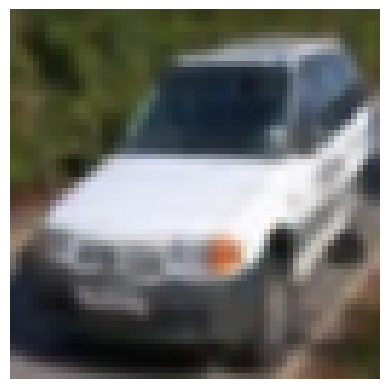

In [ ]:
img = Image.open('img46.png')
img_t = test_transform(img)

plt.imshow(img)
plt.axis('off')

### 1.1 Diffusion forward process

In this section we aim to understand and visualize the forward diffusion model. We are going to implement a linearly increased noise schedule such that $\left\{ {\beta _t  \in \left( {0,1} \right)} \right\}_{t = 1}^T$ and $\beta _1  \le \beta _2  \le  \cdots  \le \beta _T $.


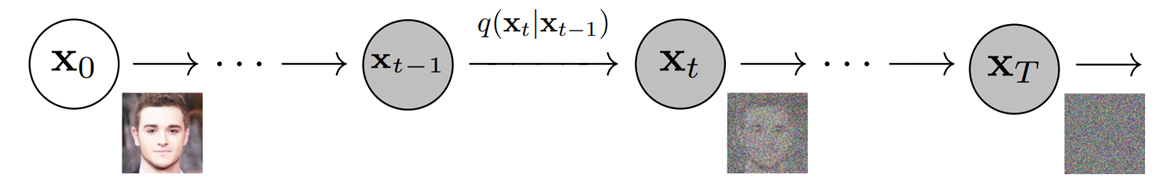

We are going to consider 1000 iterations, $T=1000$. Note that the reverse step $p$ becomes a Gaussian form only when $\beta_t$ is small $\left(\beta_t  \ll 1 \right)$.

**Task:** Implement and $\alpha_t$ and $\bar \alpha_t $ values such that $\alpha _t  = 1 - \beta _t$ and $\bar \alpha _t  = \prod\nolimits_{i = 1}^t {\alpha _i } $ using the `cumprod` torch function.

Text(0.5, 1.0, '$\\bar{\\alpha}$')

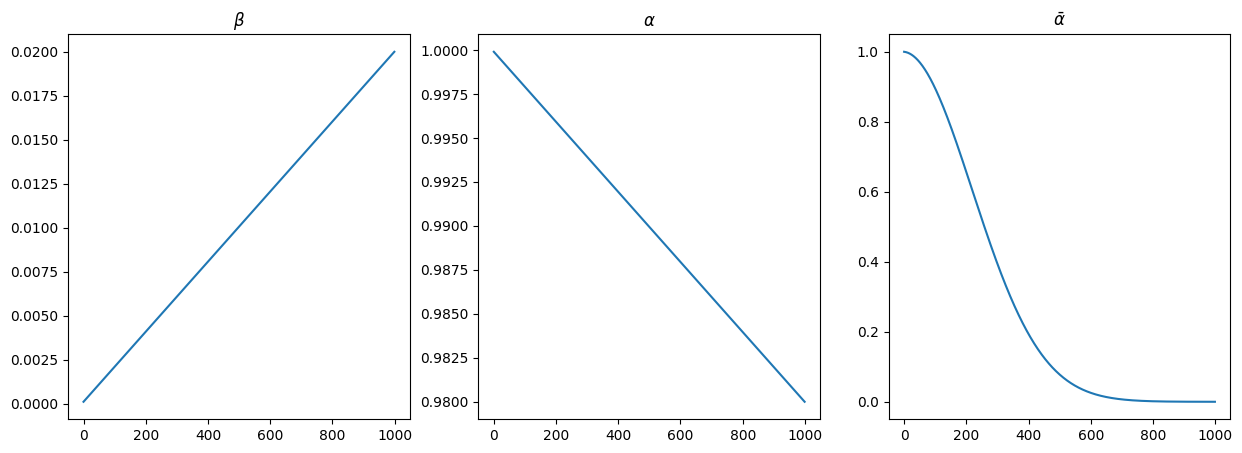

In [ ]:
import torch

noise_steps = 1000
beta_start = 0.0001
beta_end = 0.02

beta = torch.linspace(beta_start, beta_end, noise_steps)
# COMPLETE HERE
# alpha = ...
# alpha_bar = ...
# End COMPLETE HERE

[fig,axis] = plt.subplots(1,3,figsize=(15,5))

axis[0].plot(beta)
axis[0].set_title(r'$\beta$')
axis[1].plot(alpha)
axis[1].set_title(r'$\alpha$')
axis[2].plot(alpha_bar)
axis[2].set_title(r'$\bar{\alpha}$')


Now we are going to add noise to an image until the result is a Gaussian white noise image ${\bf x}_T$ such that ${\bf x}_T\sim N\left( {\bf 0},{\bf I} \right)$.

For that we are going to incrementally add the noise using the reparametrization trick. We'll implement two versions of that:
*   Incrementally, such that ${\bf{x}}_t  = \sqrt {\alpha _t } {\bf{x}}_{t - 1}  + \sqrt {1 - \alpha _t } {\bf{\epsilon }}$
*   In a single step, such that ${\bf{x}}_t = \sqrt {\bar \alpha _t } {\bf{x}}_0  + \sqrt {1 - \bar \alpha _t } {\bf{\epsilon }}$.

**Task:** Implement the functions `noise_step` for the incremental Gaussian noise adding and `diffusion_kernel` for the single step Gaussian noise adding.
You can use function `torch.randn_like` for sampling $\bf \epsilon$ from ${\bf \epsilon}\sim N\left( {\bf 0},{\bf I} \right)$.



In both cases, add 50 steps of noise using both functions and show the resulting image.

In [ ]:
# Send all variables to GPU
device = "cuda"
alpha = alpha.to(device)
alpha_bar = alpha_bar.to(device)
beta = beta.to(device)
x0 = img_t.to(device)

# Number of noising steps
t_i = 50

Incremental noising:

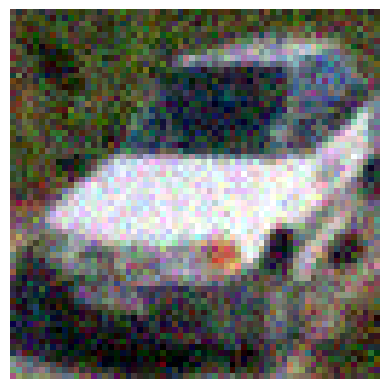

In [ ]:
def noise_step(x_tm1,t,alpha):
    # COMPLETE HERE
    # x_t =...
    # END COMPLETE HERE
    return x_t, epsilon


xt = x0 # Load variable xt with input image
for t in range(0,t_i):
    xt,epsilon = noise_step(xt,t,alpha)

plt.figure()
plt.axis('off')
plt.imshow(inverse_transform_np(xt.cpu().numpy()))

Now all in a single step!

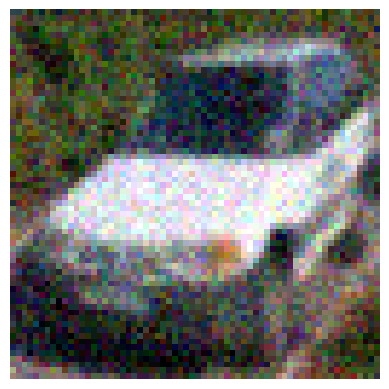

In [ ]:
def diffusion_kernel(x_0, t, alpha_bar):
    # COMPLETE HERE
    # epsilon = ...
    # x_t = ...
    # END COMPLETE HERE
    return x_t, epsilon


xt,epsilon = diffusion_kernel(x0,t_i,alpha_bar)

plt.figure()
plt.axis('off')
plt.imshow(inverse_transform_np(xt.cpu().numpy()))

### 1.2 Unconditional sampling (Inverse diffusion process)

In this part of the lab, we are not going to train any diffusion model, but only work in inference time (which is still interesting enough to learn about the diffusion process). We'll use a pre-trained model with loaded weights.

In particular, we are going to use the learned noise function $\bf \epsilon_\theta$ to denoise the original image, via the denoising step conditioned probability function $p_\theta(\mathbf{x}_{t-1}|\mathbf{x}_{t-1})$

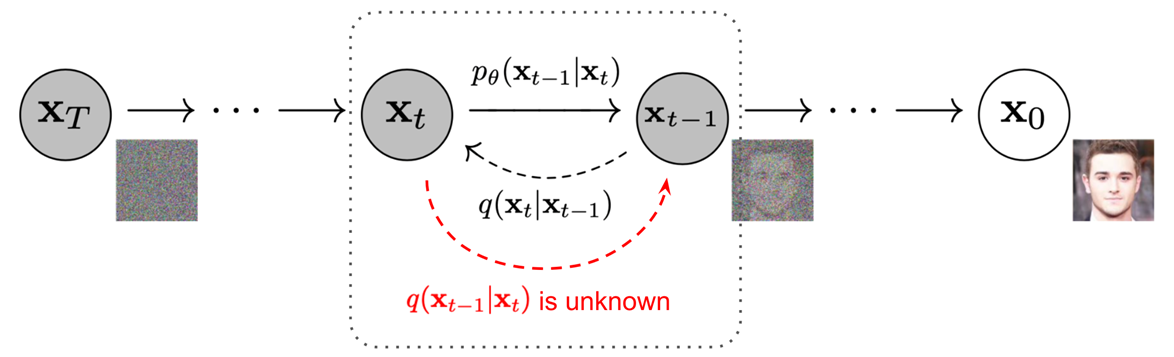

This function $\epsilon_\theta$ has been modeled with a U-Net neural network based on convolutional and self-attention layers.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
class SelfAttention(nn.Module):
    def __init__(self, channels, size):
        super(SelfAttention, self).__init__()
        self.channels = channels
        self.size = size
        self.mha = nn.MultiheadAttention(channels, 4, batch_first=True)
        self.ln = nn.LayerNorm([channels])
        self.ff_self = nn.Sequential(
            nn.LayerNorm([channels]),
            nn.Linear(channels, channels),
            nn.GELU(),
            nn.Linear(channels, channels),
        )

    def forward(self, x):
        x = x.view(-1, self.channels, self.size * self.size).swapaxes(1, 2)
        x_ln = self.ln(x)
        attention_value, _ = self.mha(x_ln, x_ln, x_ln)
        attention_value = attention_value + x
        attention_value = self.ff_self(attention_value) + attention_value
        return attention_value.swapaxes(2, 1).view(-1, self.channels, self.size, self.size)


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None, residual=False):
        super().__init__()
        self.residual = residual
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(1, mid_channels),
            nn.GELU(),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(1, out_channels),
        )

    def forward(self, x):
        if self.residual:
            return F.gelu(x + self.double_conv(x))
        else:
            return self.double_conv(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels, emb_dim=256):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, in_channels, residual=True),
            DoubleConv(in_channels, out_channels),
        )

        self.emb_layer = nn.Sequential(
            nn.SiLU(),
            nn.Linear(
                emb_dim,
                out_channels
            ),
        )

    def forward(self, x, t):
        x = self.maxpool_conv(x)
        emb = self.emb_layer(t)[:, :, None, None].repeat(1, 1, x.shape[-2], x.shape[-1])
        return x + emb


class Up(nn.Module):
    def __init__(self, in_channels, out_channels, emb_dim=256):
        super().__init__()

        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv = nn.Sequential(
            DoubleConv(in_channels, in_channels, residual=True),
            DoubleConv(in_channels, out_channels, in_channels // 2),
        )

        self.emb_layer = nn.Sequential(
            nn.SiLU(),
            nn.Linear(
                emb_dim,
                out_channels
            ),
        )

    def forward(self, x, skip_x, t):
        x = self.up(x)
        x = torch.cat([skip_x, x], dim=1)
        x = self.conv(x)
        emb = self.emb_layer(t)[:, :, None, None].repeat(1, 1, x.shape[-2], x.shape[-1])
        return x + emb

In [ ]:
class UNet(nn.Module):
    def __init__(self, c_in=3, c_out=3, time_dim=256, device="cuda"):
        super().__init__()
        self.device = device
        self.time_dim = time_dim
        self.inc = DoubleConv(c_in, 64)
        self.down1 = Down(64, 128)
        self.sa1 = SelfAttention(128, 32)
        self.down2 = Down(128, 256)
        self.sa2 = SelfAttention(256, 16)
        self.down3 = Down(256, 256)
        self.sa3 = SelfAttention(256, 8)

        self.bot1 = DoubleConv(256, 512)
        self.bot2 = DoubleConv(512, 512)
        self.bot3 = DoubleConv(512, 256)

        self.up1 = Up(512, 128)
        self.sa4 = SelfAttention(128, 16)
        self.up2 = Up(256, 64)
        self.sa5 = SelfAttention(64, 32)
        self.up3 = Up(128, 64)
        self.sa6 = SelfAttention(64, 64)
        self.outc = nn.Conv2d(64, c_out, kernel_size=1)

    def pos_encoding(self, t, channels):
        inv_freq = 1.0 / (
            10000
            ** (torch.arange(0, channels, 2, device=self.device).float() / channels)
        )
        pos_enc_a = torch.sin(t.repeat(1, channels // 2) * inv_freq)
        pos_enc_b = torch.cos(t.repeat(1, channels // 2) * inv_freq)
        pos_enc = torch.cat([pos_enc_a, pos_enc_b], dim=-1)
        return pos_enc

    def forward(self, x, t):
        t = t.unsqueeze(-1).type(torch.float)
        t = self.pos_encoding(t, self.time_dim)

        x1 = self.inc(x)
        x2 = self.down1(x1, t)
        x2 = self.sa1(x2)
        x3 = self.down2(x2, t)
        x3 = self.sa2(x3)
        x4 = self.down3(x3, t)
        x4 = self.sa3(x4)

        x4 = self.bot1(x4)
        x4 = self.bot2(x4)
        x4 = self.bot3(x4)

        x = self.up1(x4, x3, t)
        x = self.sa4(x)
        x = self.up2(x, x2, t)
        x = self.sa5(x)
        x = self.up3(x, x1, t)
        x = self.sa6(x)
        output = self.outc(x)
        return output

Notice that the input of this model is the noised image, and the particular denoising step (time).

**Q**: How is the time step introduced in the network?

In [ ]:
device = "cuda"
model = UNet(device=device).to(device)
ckpt = torch.load('unconditional_ckpt.pt')
model.load_state_dict(ckpt)

<All keys matched successfully>

Implement the denoising step function corresponding to the Gaussian approximation $p_\theta  \left( {{\bf{x}}_{t - 1} \left| {{\bf{x}}_t } \right.} \right) = N\left( {{\bf{x}}_{t - 1} ;{\bf{\mu }}_\theta  \left( {{\bf{x}}_t ,t} \right),\tilde \sigma ^2 _t {\bf{I}}} \right)$.

Notice that, since this conditioned distribution is Gaussian, for denoising the image we also have to add Gaussian white noise but with different mean and variance. In particular we have modeled the Gaussian conditioned distribution $p_\theta  \left( {{\bf{x}}_{t - 1} \left| {{\bf{x}}_t } \right.} \right) = N\left( {{\bf{x}}_{t - 1} ;{\bf{\mu }}_\theta  \left( {{\bf{x}}_t ,t} \right),\tilde \sigma ^2 _t {\bf{I}}} \right)$

with $\mu _\theta  \left( {{\bf{x}}_t ,t} \right) = \frac{1}{{\sqrt {\alpha _t } }}\left( {{\bf{x}}_t  - \frac{{\beta _t }}{{\sqrt {1 - \bar \alpha _t } }}{\bf{\epsilon }}_\theta  \left( {{\bf{x}}_t ,t} \right)} \right)$ and $\tilde \sigma ^2 _t  = \frac{{1 - \bar \alpha _{t - 1} }}{{1 - \bar \alpha _t }}\beta _t$ such that  
${\bf{x}}_{t-1}  = \frac{1}{{\sqrt {\alpha _t } }}\left( {{\bf{x}}_{t}  - \frac{{\beta _t }}{{\sqrt {1 - \bar \alpha _t } }}{\bf{\epsilon }}_\theta  \left( {{\bf{x}}_{t} ,t} \right)} \right) + \sqrt {\frac{{1 - \bar \alpha _{t - 1} }}{{1 - \bar \alpha _t }}\beta _t } {\bf{\epsilon }}$ where ${\bf \epsilon}\sim N\left( {\bf 0},{\bf I} \right)$.

As before you can sample from $p_\theta  \left( {{\bf{x}}_{t - 1} \left| {{\bf{x}}_t } \right.} \right) = N\left( {{\bf{x}}_{t - 1} ;{\bf{\mu }}_\theta  \left( {{\bf{x}}_t ,t} \right),\tilde \sigma ^2 _t {\bf{I}}} \right)$ using the reparametrization trick by sampling the normal distribution ${\bf \epsilon}\sim N\left( {\bf 0},{\bf I} \right)$ with `torch.randn_like(xt)`.






Run a denoising step (from 50 to 49) and visualize the predicted noise and the denoised image.

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

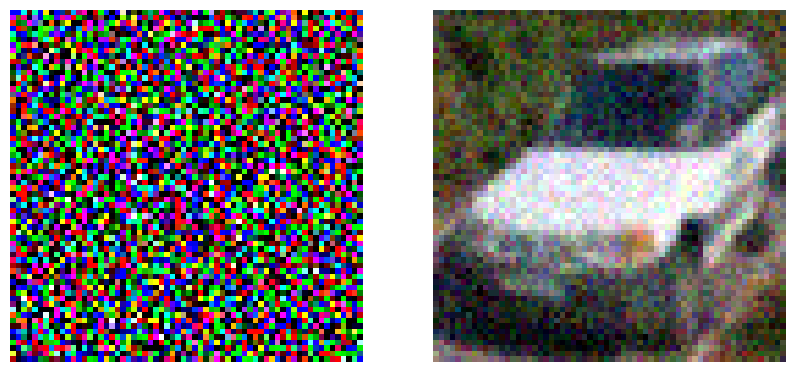

In [ ]:
predicted_noise = model(xt.unsqueeze(0),torch.tensor([t_i]).to(device))

# COMPLETE HERE
#x_tm1 = ....
# End of COMPLETE HERE

fig, axis = plt.subplots(1, 2, figsize=(10, 5))
axis[0].imshow(predicted_noise[0].cpu().permute(1,2,0).detach().numpy())
axis[0].axis('off')
axis[1].imshow(inverse_transform_np(x_tm1[0].cpu().detach().numpy()))
axis[1].axis('off')


Now, implement the complete sequence of denoising steps for obtaining a denoised image. Notice that for $t=0$ we are not going to add Gaussian noise because $p_\theta  \left( {{\bf{x}}_0 \left| {{\bf{x}}_1 } \right.} \right)$ is not modeled with a Gaussian distribution. Instead, we will just add the mean of  $p_\theta  \left( {{\bf{x}}_{t - 1} \left| {{\bf{x}}_t } \right.} \right)$  by convention.


In [ ]:
n = 1 # Number of images to generate
model.eval()
x = xt.unsqueeze(0)

49it [00:01, 44.59it/s]


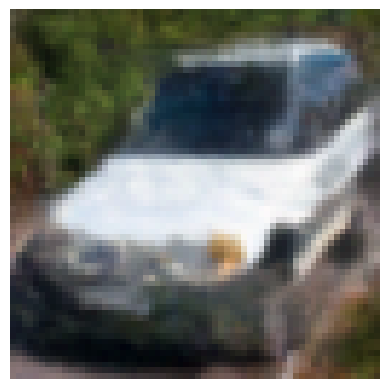

In [ ]:
from tqdm import tqdm
# Denoising
with torch.no_grad():
    for i in tqdm(reversed(range(1, t_i)), position=0):

        t = (torch.ones(n) * i).long().to(device)
        predicted_noise = model(x, t)
        alpha_ = alpha[t][:, None, None, None]
        alpha_bar_ = alpha_bar[t][:, None, None, None]
        alpha_bar_m1 = alpha_bar[t-1][:, None, None, None]
        beta_ = beta[t][:, None, None, None]

        if i > 1:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        # COMPLETE HERE
        # x = ...
        # END COMPLETE HERE

plt.figure()
plt.axis('off')
plt.imshow(inverse_transform_np(x[0].cpu().numpy()))

**Task**: Try denoising the image using a larger number of timesteps (e.g., 500).

**Q:** Do you still end up with an image of a car?

Now, instead of denoising the noisy image we are going to directly sample random noise from the latent space and generate the images, using the reparametrization trick with ${\bf \epsilon}\sim N\left( {\bf 0},{\bf I} \right)$

999it [02:03,  8.07it/s]


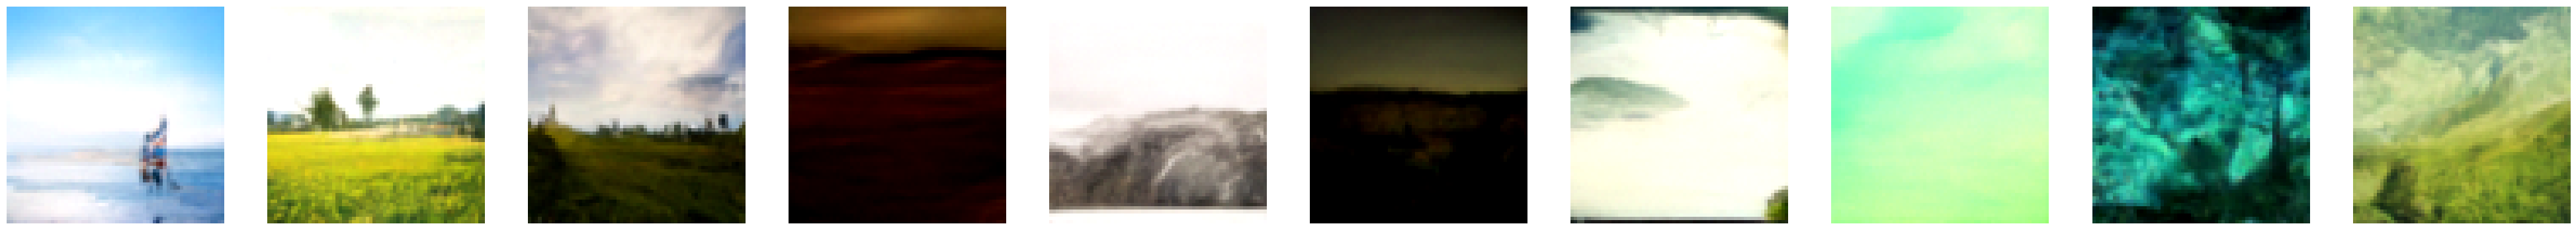

In [ ]:
n = 10 # Number of images to generate
with torch.no_grad():
    # COMPLETE HERE
    #x = ...
    # End of COMPLETE HERE

    for i in tqdm(reversed(range(1, noise_steps)), position=0):
        t = (torch.ones(n) * i).long().to(device)
        predicted_noise = model(x, t)
        alpha_ = alpha[t][:, None, None, None]
        alpha_bar_ = alpha_bar[t][:, None, None, None]
        alpha_bar_m1 = alpha_bar[t-1][:, None, None, None]
        beta_ = beta[t][:, None, None, None]
        if i > 1:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        # COMPLETE HERE
        # x = ...
        # End of COMPLETE HERE


fig, axis = plt.subplots(1, 10, figsize=(5*10, 5))

for k in range(n):
    axis[k].imshow(inverse_transform_np(x[k].cpu().detach().numpy()))
    axis[k].axis('off')



**Q:** And now? are you getting cars? What kind of images are you getting?

### 1.3. Conditional sampling (Inverse diffusion process)

We are going to sample images from a conditional model. This means, we are going to guide the image generation towards certain predefined condition, in this case, a label.

Therefore, the model now is going to be different, with the following inputs `model(x,t,y)` where `y` is the label when using the conditional case and `model(x,t,None)` for the unconditional case.

Here you have the following UNet model:


In [ ]:
class UNet_conditional(nn.Module):
    def __init__(self, c_in=3, c_out=3, time_dim=256, num_classes=None, device="cuda"):
        super().__init__()
        self.device = device
        self.time_dim = time_dim
        self.inc = DoubleConv(c_in, 64)
        self.down1 = Down(64, 128)
        self.sa1 = SelfAttention(128, 32)
        self.down2 = Down(128, 256)
        self.sa2 = SelfAttention(256, 16)
        self.down3 = Down(256, 256)
        self.sa3 = SelfAttention(256, 8)

        self.bot1 = DoubleConv(256, 512)
        self.bot2 = DoubleConv(512, 512)
        self.bot3 = DoubleConv(512, 256)

        self.up1 = Up(512, 128)
        self.sa4 = SelfAttention(128, 16)
        self.up2 = Up(256, 64)
        self.sa5 = SelfAttention(64, 32)
        self.up3 = Up(128, 64)
        self.sa6 = SelfAttention(64, 64)
        self.outc = nn.Conv2d(64, c_out, kernel_size=1)

        if num_classes is not None:
            self.label_emb = nn.Embedding(num_classes, time_dim)

    def pos_encoding(self, t, channels):
        inv_freq = 1.0 / (
            10000
            ** (torch.arange(0, channels, 2, device=self.device).float() / channels)
        )
        pos_enc_a = torch.sin(t.repeat(1, channels // 2) * inv_freq)
        pos_enc_b = torch.cos(t.repeat(1, channels // 2) * inv_freq)
        pos_enc = torch.cat([pos_enc_a, pos_enc_b], dim=-1)
        return pos_enc

    def forward(self, x, t, y):
        t = t.unsqueeze(-1).type(torch.float)
        t = self.pos_encoding(t, self.time_dim)

        if y is not None:
            t += self.label_emb(y)

        x1 = self.inc(x)
        x2 = self.down1(x1, t)
        x2 = self.sa1(x2)
        x3 = self.down2(x2, t)
        x3 = self.sa2(x3)
        x4 = self.down3(x3, t)
        x4 = self.sa3(x4)

        x4 = self.bot1(x4)
        x4 = self.bot2(x4)
        x4 = self.bot3(x4)

        x = self.up1(x4, x3, t)
        x = self.sa4(x)
        x = self.up2(x, x2, t)
        x = self.sa5(x)
        x = self.up3(x, x1, t)
        x = self.sa6(x)
        output = self.outc(x)
        return output

If you observe the code, you will see the label is mapped into an embedding that is directly added to the timestep positional encoding.

**Q:** What is the size of the label embedding then?


Now let's load the weights:

In [ ]:
device = "cuda"
model = UNet_conditional(num_classes=10).to(device)
ckpt = torch.load("conditional_ema_ckpt.pt")
model.load_state_dict(ckpt)

<All keys matched successfully>

In order to condition the model, we'll need to choose a label so that the generated images should be similar to the corresponding images in the dataset of such class. We'll select the label using the `label_id` variable, which initially is set to 'cat'

In [ ]:
n = 10 # Number of images to generate
model.eval()
labels_text_list = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
label_id = 3
labels = torch.tensor([label_id]).to(device)

In Classifier-Free Guidance methods, we'll leverage both the conditional and unconditional diffusion models via extrapolation (as shown in the class slides):

$\epsilon_\theta^{guided}(\mathbf{x}_t,y,t) = (1+\omega)\epsilon_\theta(\mathbf{x}_t,y,t) - \omega \epsilon_\theta(\mathbf{x}_t,\phi,t)$

where $\phi$ means the null label (unconditional case) and $\omega$ is the scaling coefficient (`cfg_scale` in the code)

In [ ]:

cfg_scale = 3

with torch.no_grad():
    # COMPLETE HERE
    #x = ...
    # End of COMPLETE HERE

    for i in tqdm(reversed(range(1, noise_steps)), position=0):
        t = (torch.ones(n) * i).long().to(device)
        predicted_noise = model(x, t, labels)
        # COMPLETE HERE the Classifier Free Guidance
        # predicted_noise = ...
        # END COMPLETE HERE

        if i > 1:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        alpha_ = alpha[t][:, None, None, None]
        alpha_bar_ = alpha_bar[t][:, None, None, None]
        alpha_bar_m1 = alpha_bar[t-1][:, None, None, None]
        beta_ = beta[t][:, None, None, None]
        # COMPLETE HERE
        # x = ...
        # END COMPLETE HERE

999it [04:11,  3.98it/s]


Finally, plot the results.

**Q:** Do you think the results resemble the class you conditioned the model with?

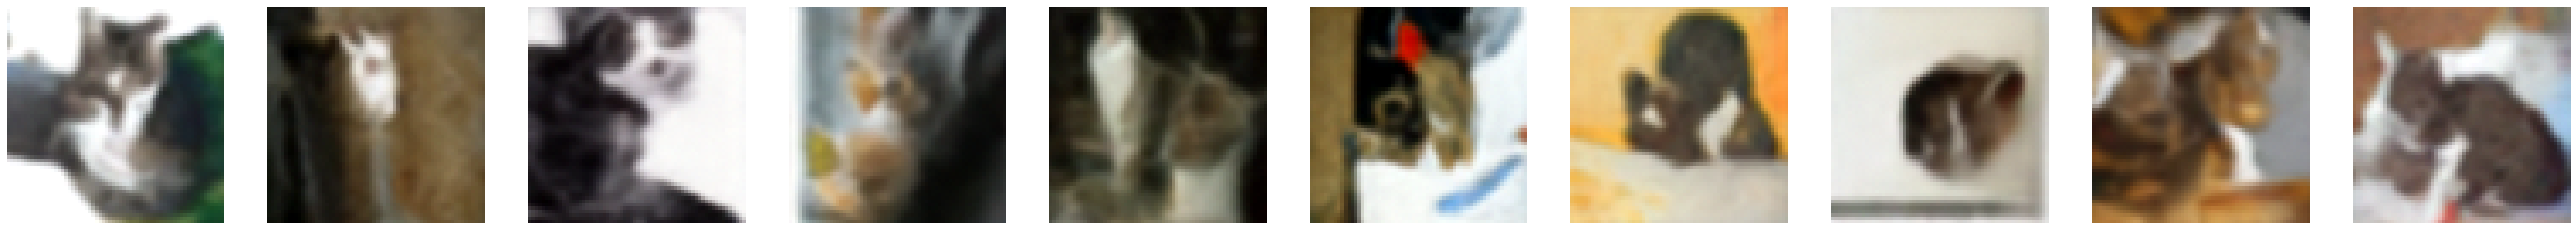

In [ ]:
fig, axis = plt.subplots(1, 10, figsize=(5*10, 5))

for k in range(n):
    axis[k].imshow(inverse_transform_np(x[k].cpu().detach().numpy()))
    axis[k].axis('off')

### 1.4. (OPTIONAL) Training the diffusion model

Below there are some cells that will let you train the model we've been using in this lab. It is not as thoroughly commented as previous parts, but should be relatively easy to follow if you've been following these lab sessions. Be aware that you need to complete a little bit of code (it should be easy with what you've done up to this point).

For this part, you need to upload the complete CIFAR10 dataset (64 pixel version) and unzip it.

This part is **optional**: if you are curious you can run it to train the model by yourself. But be warned: it may take a looong time.

In [ ]:
torch.cuda.synchronize()
del model
del ckpt
del xt
del x0
del epsilon
torch.cuda.empty_cache()

In [ ]:
# Dataloader
from torch.utils.data import DataLoader

dataset_path = r"../cifar10-64/train"
dataset = torchvision.datasets.ImageFolder(dataset_path, transform=train_transform)
dataloader = DataLoader(dataset, batch_size=6, shuffle=True)


In [ ]:

num_classes = 10
model = UNet_conditional(num_classes=num_classes).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
mse = nn.MSELoss()

l = len(dataloader)


In [ ]:
import copy
class EMA:
    def __init__(self, beta):
        super().__init__()
        self.beta = beta
        self.step = 0

    def update_model_average(self, ma_model, current_model):
        for current_params, ma_params in zip(current_model.parameters(), ma_model.parameters()):
            old_weight, up_weight = ma_params.data, current_params.data
            ma_params.data = self.update_average(old_weight, up_weight)

    def update_average(self, old, new):
        if old is None:
            return new
        return old * self.beta + (1 - self.beta) * new

    def step_ema(self, ema_model, model, step_start_ema=2000):
        if self.step < step_start_ema:
            self.reset_parameters(ema_model, model)
            self.step += 1
            return
        self.update_model_average(ema_model, model)
        self.step += 1

    def reset_parameters(self, ema_model, model):
        ema_model.load_state_dict(model.state_dict())

ema = EMA(0.995)
ema_model = copy.deepcopy(model).eval().requires_grad_(False)

In [ ]:
def diffusion_kernel(x_0, t, alpha_bar):
    sqrt_alpha_bar = torch.sqrt(alpha_bar[t])[:, None, None, None]
    sqrt_one_minus_alpha_bar = torch.sqrt(1 - alpha_bar[t])[:, None, None, None]
    # COMPLETE HERE
    #epsilon = ...
    #x_t = ...
    # END COMPLETE HERE
    return x_t, epsilon

epochs = 300
for epoch in range(epochs):
    pbar = tqdm(dataloader)
    for i, (images, labels) in enumerate(pbar):
        images = images.to(device)
        labels = labels.to(device)
        t = torch.randint(low=1, high=noise_steps, size=(images.shape[0],)).to(device)
        x_t, noise = diffusion_kernel(images, t, alpha_bar)
        if np.random.random() < 0.1:
            labels = None
        predicted_noise = model(x_t, t, labels)
        loss = mse(noise, predicted_noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        ema.step_ema(ema_model, model)

        pbar.set_postfix(MSE=loss.item())

  3%|▎         | 280/8334 [33:10<15:54:08,  7.11s/it, MSE=0.0616]


KeyboardInterrupt: 